# fMRI Neurofeedback Pilot for DMN–Insula Modulation  
## Tata-oriented version: fMRI networks with future EEG translation

This notebook is a research-planning and pilot-analysis template for a PhD direction combining:
- functional brain networks
- internal cognition / rumination / anxiety
- fMRI neurofeedback
- later EEG translation


## Research question

Can participants learn to modulate Default Mode Network (DMN) activity and DMN–insula coupling, and could those targets later be approximated with EEG?


In [ ]:
# Install in VS Code if needed:
# %pip install nilearn nibabel matplotlib numpy pandas scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from nilearn import datasets
    from nilearn.maskers import NiftiLabelsMasker
    from nilearn.connectome import ConnectivityMeasure
    NILEARN_OK = True
except Exception as e:
    NILEARN_OK = False
    print("Nilearn not available yet:", e)

## Step 1 — Load a sample fMRI dataset

This uses a nilearn developmental resting-state sample as a stand-in for an open-data workflow.


In [2]:
if NILEARN_OK:
    dataset = datasets.fetch_development_fmri(n_subjects=1)
    fmri_file = dataset.func[0]
    confounds_file = dataset.confounds[0]
    print("fMRI file:", fmri_file)
    print("Confounds:", confounds_file)
else:
    print("Install nilearn first.")

[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
fMRI file: /home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Confounds: /home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv


## Step 2 — Extract atlas-based regional time series

In [3]:
if NILEARN_OK:
    atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
    masker = NiftiLabelsMasker(
        labels_img=atlas.maps,
        standardize='zscore_sample',
        detrend=True,
        low_pass=0.10,
        high_pass=0.01,
        t_r=2.0
    )
    time_series = masker.fit_transform(fmri_file)
    print("Time-series shape:", time_series.shape)
else:
    time_series = None

[fetch_atlas_schaefer_2018] Dataset found in /home/john-walkey/nilearn_data/schaefer_2018
[fetch_atlas_schaefer_2018] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_100Parcels_7Networks_order.txt ...
[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_1mm.nii.gz ...
[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

Time-series shape: (168, 100)


## Step 3 — Connectivity matrix

/tmp/ipykernel_6635/22670403.py:3: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  corr_matrix = conn.fit_transform([time_series])[0]


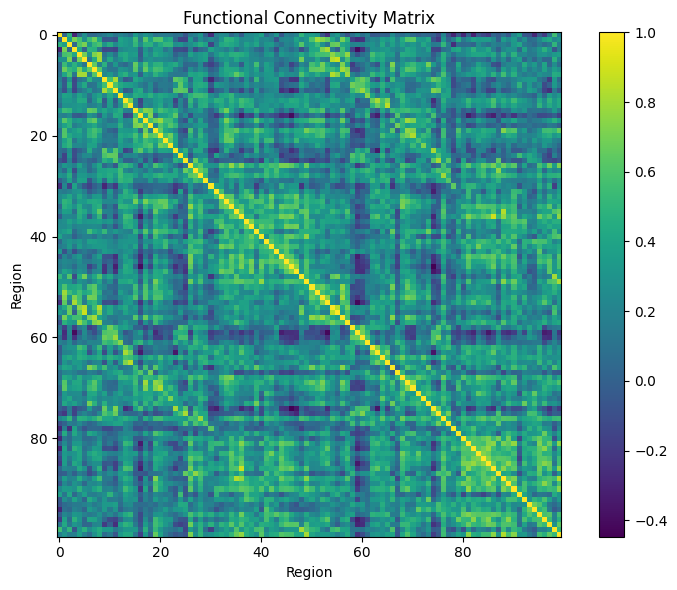

In [4]:
if time_series is not None:
    conn = ConnectivityMeasure(kind='correlation')
    corr_matrix = conn.fit_transform([time_series])[0]

    plt.figure(figsize=(8, 6))
    plt.imshow(corr_matrix, interpolation='nearest')
    plt.colorbar()
    plt.title("Functional Connectivity Matrix")
    plt.xlabel("Region")
    plt.ylabel("Region")
    plt.tight_layout()
    plt.show()

## Step 4 — DMN and insula proxy signals

These node indices are placeholders for a pilot demonstration only.


In [5]:
if time_series is not None:
    dmn_nodes = list(range(10, 20))
    insula_nodes = [30, 31, 32, 33]

    dmn_signal = np.mean(time_series[:, dmn_nodes], axis=1)
    insula_signal = np.mean(time_series[:, insula_nodes], axis=1)

    print("DMN signal length:", len(dmn_signal))
    print("Insula signal length:", len(insula_signal))

DMN signal length: 168
Insula signal length: 168


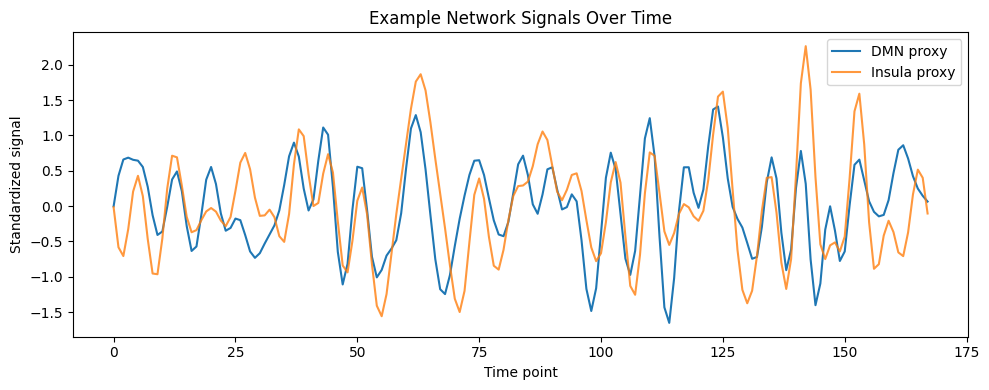

In [6]:
if time_series is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(dmn_signal, label='DMN proxy')
    plt.plot(insula_signal, label='Insula proxy', alpha=0.8)
    plt.title("Example Network Signals Over Time")
    plt.xlabel("Time point")
    plt.ylabel("Standardized signal")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Step 5 — Simple neurofeedback target

Here the target is a simple combination:
feedback = lower DMN + higher insula


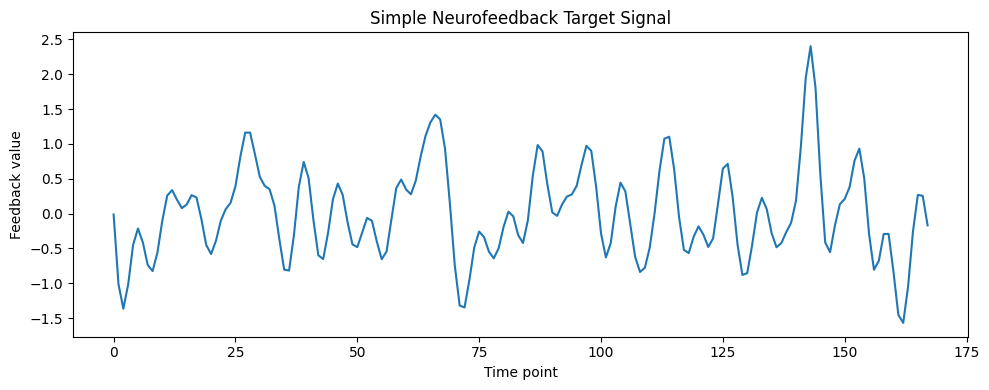

In [7]:
if time_series is not None:
    feedback_signal = (-1.0 * dmn_signal) + (1.0 * insula_signal)

    plt.figure(figsize=(10, 4))
    plt.plot(feedback_signal)
    plt.title("Simple Neurofeedback Target Signal")
    plt.xlabel("Time point")
    plt.ylabel("Feedback value")
    plt.tight_layout()
    plt.show()

## Step 6 — Sliding-window DMN–insula coupling

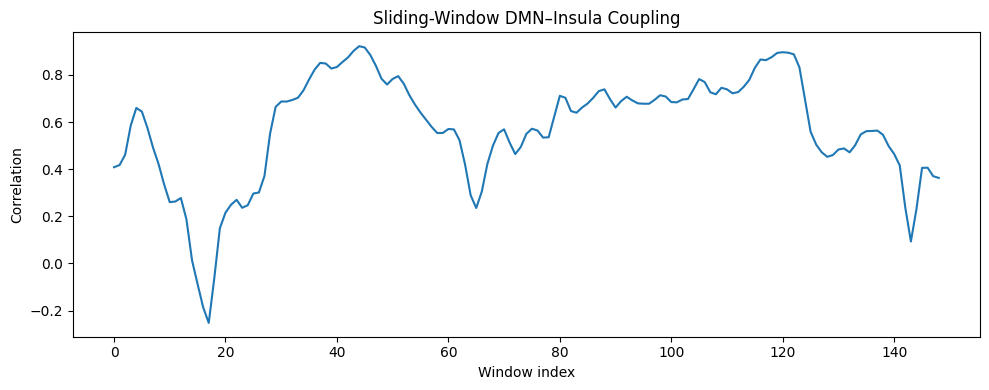

In [8]:
def sliding_correlation(x, y, window=20):
    vals = []
    for i in range(len(x) - window + 1):
        vals.append(np.corrcoef(x[i:i+window], y[i:i+window])[0, 1])
    return np.array(vals)

if time_series is not None:
    dmn_insula_coupling = sliding_correlation(dmn_signal, insula_signal, window=20)

    plt.figure(figsize=(10, 4))
    plt.plot(dmn_insula_coupling)
    plt.title("Sliding-Window DMN–Insula Coupling")
    plt.xlabel("Window index")
    plt.ylabel("Correlation")
    plt.tight_layout()
    plt.show()

## Step 7 — Toy modulation / learning simulation

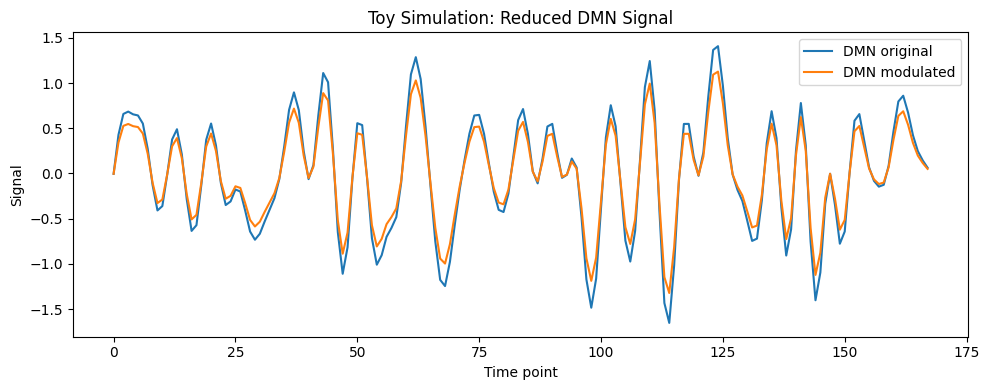

In [9]:
if time_series is not None:
    modulated = time_series.copy()
    modulated[:, dmn_nodes] *= 0.80
    modulated[:, insula_nodes] *= 1.10

    dmn_mod = np.mean(modulated[:, dmn_nodes], axis=1)
    insula_mod = np.mean(modulated[:, insula_nodes], axis=1)

    plt.figure(figsize=(10, 4))
    plt.plot(dmn_signal, label='DMN original')
    plt.plot(dmn_mod, label='DMN modulated')
    plt.legend()
    plt.title("Toy Simulation: Reduced DMN Signal")
    plt.xlabel("Time point")
    plt.ylabel("Signal")
    plt.tight_layout()
    plt.show()

In [10]:
if time_series is not None:
    corr_before = np.corrcoef(dmn_signal, insula_signal)[0, 1]
    corr_after = np.corrcoef(dmn_mod, insula_mod)[0, 1]
    print("DMN–insula correlation before:", round(float(corr_before), 3))
    print("DMN–insula correlation after: ", round(float(corr_after), 3))

DMN–insula correlation before: 0.547
DMN–insula correlation after:  0.547


## Step 8 — EEG translation idea

A strong translational framing is:

1. use fMRI to define the network target  
2. search for EEG features that track that target  
3. build cheaper EEG neurofeedback later  

Candidate EEG features to explore:
- alpha power
- theta/beta balance
- frontal midline theta
- posterior alpha
- coherence/connectivity measures


## Step 9 — Good next upgrades

- replace placeholder node lists with exact atlas labels
- add explicit motion/confound regression
- compare multiple participants
- relate connectivity to trait-anxiety scores
- export figures for your slides and PI email
